In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Wilson-Cowan Model

The **Wilson-Cowan model** describes the coupled dynamics of an excitatory population rate $r_E$ and an inhibitory population rate $r_I$ through sigmoidal firing-rate functions:

$$\tau_E\dot r_E = -r_E + S_E(w_{EE} r_E - w_{EI} r_I + I_E),\qquad \tau_I\dot r_I = -r_I + S_I(w_{IE} r_E - w_{II} r_I + I_I).$$

Depending on the synaptic weights and inputs the model exhibits a stable low-activity state, multistability, or sustained oscillations from the excitatory-inhibitory loop. It is the classic two-population mean-field model of cortical dynamics.

**Reference:** Wilson & Cowan (1972), *Excitatory and inhibitory interactions in localized populations of model neurons*, Biophysical Journal 12(1):1-24.

## Build the model

We choose weights and a drive that put the E-I loop into a limit-cycle (oscillatory) regime.

In [2]:
node = brainmass.WilsonCowanStep(
    in_size=1, tau_E=2.5 * u.ms, tau_I=3.75 * u.ms,
    wEE=16.0, wEI=12.0, wIE=15.0, wII=3.0)
node

WilsonCowanStep(
  in_size=(1,),
  out_size=(1,),
  rE_init=Constant(value=0.0),
  rI_init=Constant(value=0.0),
  method=exp_euler,
  a_E=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1.2, dtype=float32)
  ),
  a_I=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1., dtype=float32)
  ),
  tau_E=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(2.5, "ms")
  ),
  tau_I=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(3.75, "ms")
  ),
  theta_E=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(2.8, dtype=float32)
  ),
  theta_I=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(4., dtype=float32)
  ),
  wEE=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(16., dtype=float32)
  ),
  wIE=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(15., dtype=float32)
  ),
  wEI=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=

## Run a simulation

In [3]:
sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(300. * u.ms, inputs=lambda i, t: (1.0, 0.0),
              monitors=['rE', 'rI'], transient=50. * u.ms)
res['rE'].shape

(2500, 1)

## Visualize

E and I rates oscillate out of phase; the phase portrait shows the E-I limit cycle.

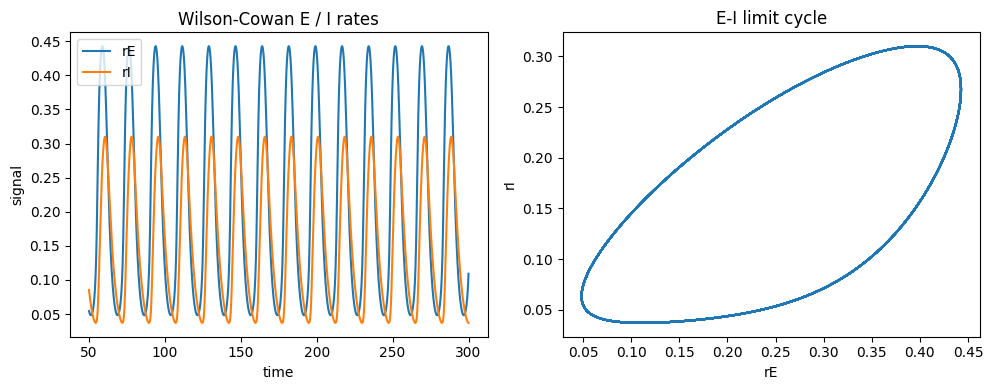

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
brainmass.viz.plot_timeseries(
    jnp.concatenate([res['rE'], res['rI']], axis=1), ts=res['ts'],
    labels=['rE', 'rI'], ax=axes[0])
axes[0].set_title('Wilson-Cowan E / I rates')
brainmass.viz.plot_phase_portrait(res['rE'], res['rI'], ax=axes[1])
axes[1].set_xlabel('rE'); axes[1].set_ylabel('rI')
axes[1].set_title('E-I limit cycle')
plt.tight_layout()
plt.show()

## Try it: vary the excitatory drive

The external drive to the E population moves the node between quiescence, oscillation, and high steady activity.

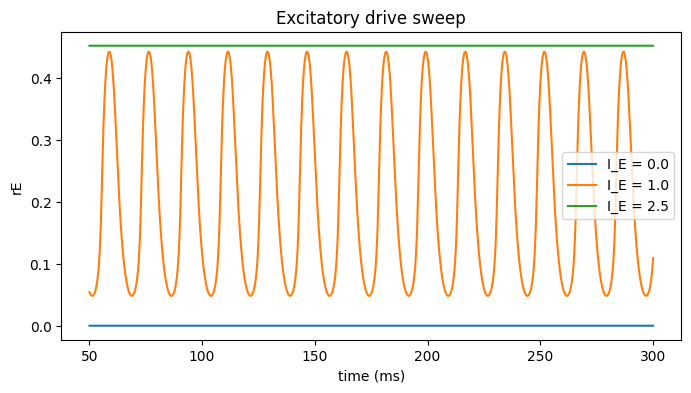

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for drive in [0.0, 1.0, 2.5]:
    m = brainmass.WilsonCowanStep(
        in_size=1, tau_E=2.5 * u.ms, tau_I=3.75 * u.ms,
        wEE=16.0, wEI=12.0, wIE=15.0, wII=3.0)
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(
        300. * u.ms, inputs=lambda i, t, d=drive: (d, 0.0),
        monitors=['rE'], transient=50. * u.ms)
    ax.plot(u.get_magnitude(r['ts']), u.get_magnitude(r['rE'])[:, 0],
            label=f'I_E = {drive}')
ax.set_xlabel('time (ms)'); ax.set_ylabel('rE'); ax.legend()
ax.set_title('Excitatory drive sweep')
plt.show()